In [1]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
%matplotlib inline
import sys
import os
sys.path.append('../../results_analysis')
from utils import generate_anndata_from_cell_table
base_dir = "../../../"
import logging
logging.basicConfig(level=logging.DEBUG)


In [2]:
!ls data/

sc_protein.h5ad


In [ ]:
reload =False
file_name = 'data/sc_protein_qc.h5ad'
if reload:
    adata = sc.read_h5ad(file_name)
else:
    adata = generate_anndata_from_cell_table(cell_table_path=base_dir+'segmentation/cell_table_Denoised/cell_table_size_normalized_cell_labels.csv',biosamples_path=base_dir+'IMC_data/ExtraDocs/processed_response.csv')
    channels = ['CD38', 'CD14', 'Tbet', 'CD16', 'CD163',
       'Pan-keratin', 'CD11b', 'CD107a', 'CD45', 'CD44', 'CD366',
       'FOXP3', 'CD4', 'E-Cadherin', 'CD68', 'HLA-DR-DQ-DP', 'CD20',
       'CD8a', 'Beta-Catenin', 'B7-H4', 'Granzyme-B',
       'CD3', 'CD27', 'CD45RO',
       'Alpha-SMA', 'Vimentin', 'CD31' ]
    logging.info('generated adata')
    adata.var['marker_channel'] = adata.var.index.isin(channels)
    adata.full = adata
    #filter for phenotype marker only
    adata=adata[:,adata.var.marker_channel]

    
    sc.tl.pca(adata)
    sc.external.tl.phenograph(adata, clustering_algo="louvain", k=30)
    #consider whether to overwrite
    data_folder = 'data/'
    if not os.path.exists(data_folder):
        os.makedirs(data_folder)
    adata.write(file_name)

INFO:root:Finished loading, now create the anndata object
/home/giuseppe/anaconda3/envs/rapids-23.10/lib/python3.10/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


If one fancies umap


In [3]:
sc.pp.neighbors(adata, n_neighbors=10,method = 'rapids')
sc.tl.umap(adata,method = 'rapids')

/home/giuseppe/anaconda3/envs/rapids-23.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2023-11-23 17:02:25.952466: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-11-23 17:02:25.987139: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2023-11-23 17:02:25.987174: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2023-1

In [5]:
biosamples_path=base_dir+'IMC_data/ExtraDocs/processed_response.csv'
biosamples =pd.read_csv(biosamples_path)

In [36]:
adata = sc.AnnData(intensities_protein, obsm={"spatial": cell_table[['centroid-0', 'centroid-1']].values})
adata.obs['acquisition_ID'] = cell_table.fov.values
adata.obs['Leap_ID'] = adata.obs.acquisition_ID.str.split('_',n = 1).str[0].str.upper()

/home/giuseppe/anaconda3/envs/rapids-23.10/lib/python3.10/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [50]:
a = adata.obs.copy()
adata.obs.reset_index().merge(biosamples,left_on='Leap_ID',right_on= 'LEAP_ID').drop(['LEAP_ID'],axis = 1).set_index('index')

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '3964186', '3964187', '3964188', '3964189', '3964190', '3964191',
       '3964192', '3964193', '3964194', '3964195'],
      dtype='object', name='index', length=3964196)

In [51]:

#cell_table_path=base_dir+'segmentation/cell_table_Denoised/cell_table_size_normalized_cell_labels.csv'
#cell_table = pd.read_csv(cell_table_path)
#intensities_protein = cell_table.iloc[:,1:cell_table.columns.get_loc('label')]#proteins are from the second columns up to the column called label


adata.obs['acquisition_ID'] = cell_table.fov.values
adata.obs['Leap_ID'] = adata.obs.acquisition_ID.str.split('_',n = 1).str[0].str.upper()
adata.obs = adata.obs.reset_index().merge(biosamples,left_on='Leap_ID',right_on= 'LEAP_ID').drop(['LEAP_ID'],axis = 1).set_index('index')
#adata.obs['qc_pass'] = cell_table['qc_pass'].values
# get fovs having more than 1000 cells
#fovs = adata.obs.acquisition_ID.value_counts()[adata.obs.acquisition_ID.value_counts()>=1000].index


In [53]:
fovs = adata.obs.acquisition_ID.value_counts()[adata.obs.acquisition_ID.value_counts()>=1000].index
adata[adata.obs.acquisition_ID.isin(fovs)]

View of AnnData object with n_obs × n_vars = 3938981 × 38
    obs: 'acquisition_ID', 'Leap_ID', 'SLIDE_NUMBER', 'BIOBANK_ID', 'SAMPLE_TYPE_(CORE/RESECTION)', 'FORMAT_(FFPE/FROZEN)', 'FORCE_TRIAL?_(Y/N)', 'DATE_SECTIONED', 'H&E_NOTES', 'ST_NOTES', 'Response', 'COMMENTS', 'note_if_frozen_(otherwise_FFPE)', 'Extreme_non-responder_(death_within_2_years?)'
    obsm: 'spatial'

In [20]:
adata.obs['pheno_louvain']

0          58
2          58
3          58
4          58
5          43
           ..
3964191     7
3964192     7
3964193     1
3964194     4
3964195    12
Name: pheno_louvain, Length: 3013318, dtype: category
Categories (79, int64): [0, 1, 2, 3, ..., 75, 76, 77, 78]

In [3]:
cluster_mean_expr = pd.DataFrame()
for cluster,cell_ids in adata.obs.groupby('pheno_louvain').groups.items():
    cluster_mean_expr[cluster] =adata[cell_ids].X.mean(axis = 0)
cluster_mean_expr.index = adata.var.index

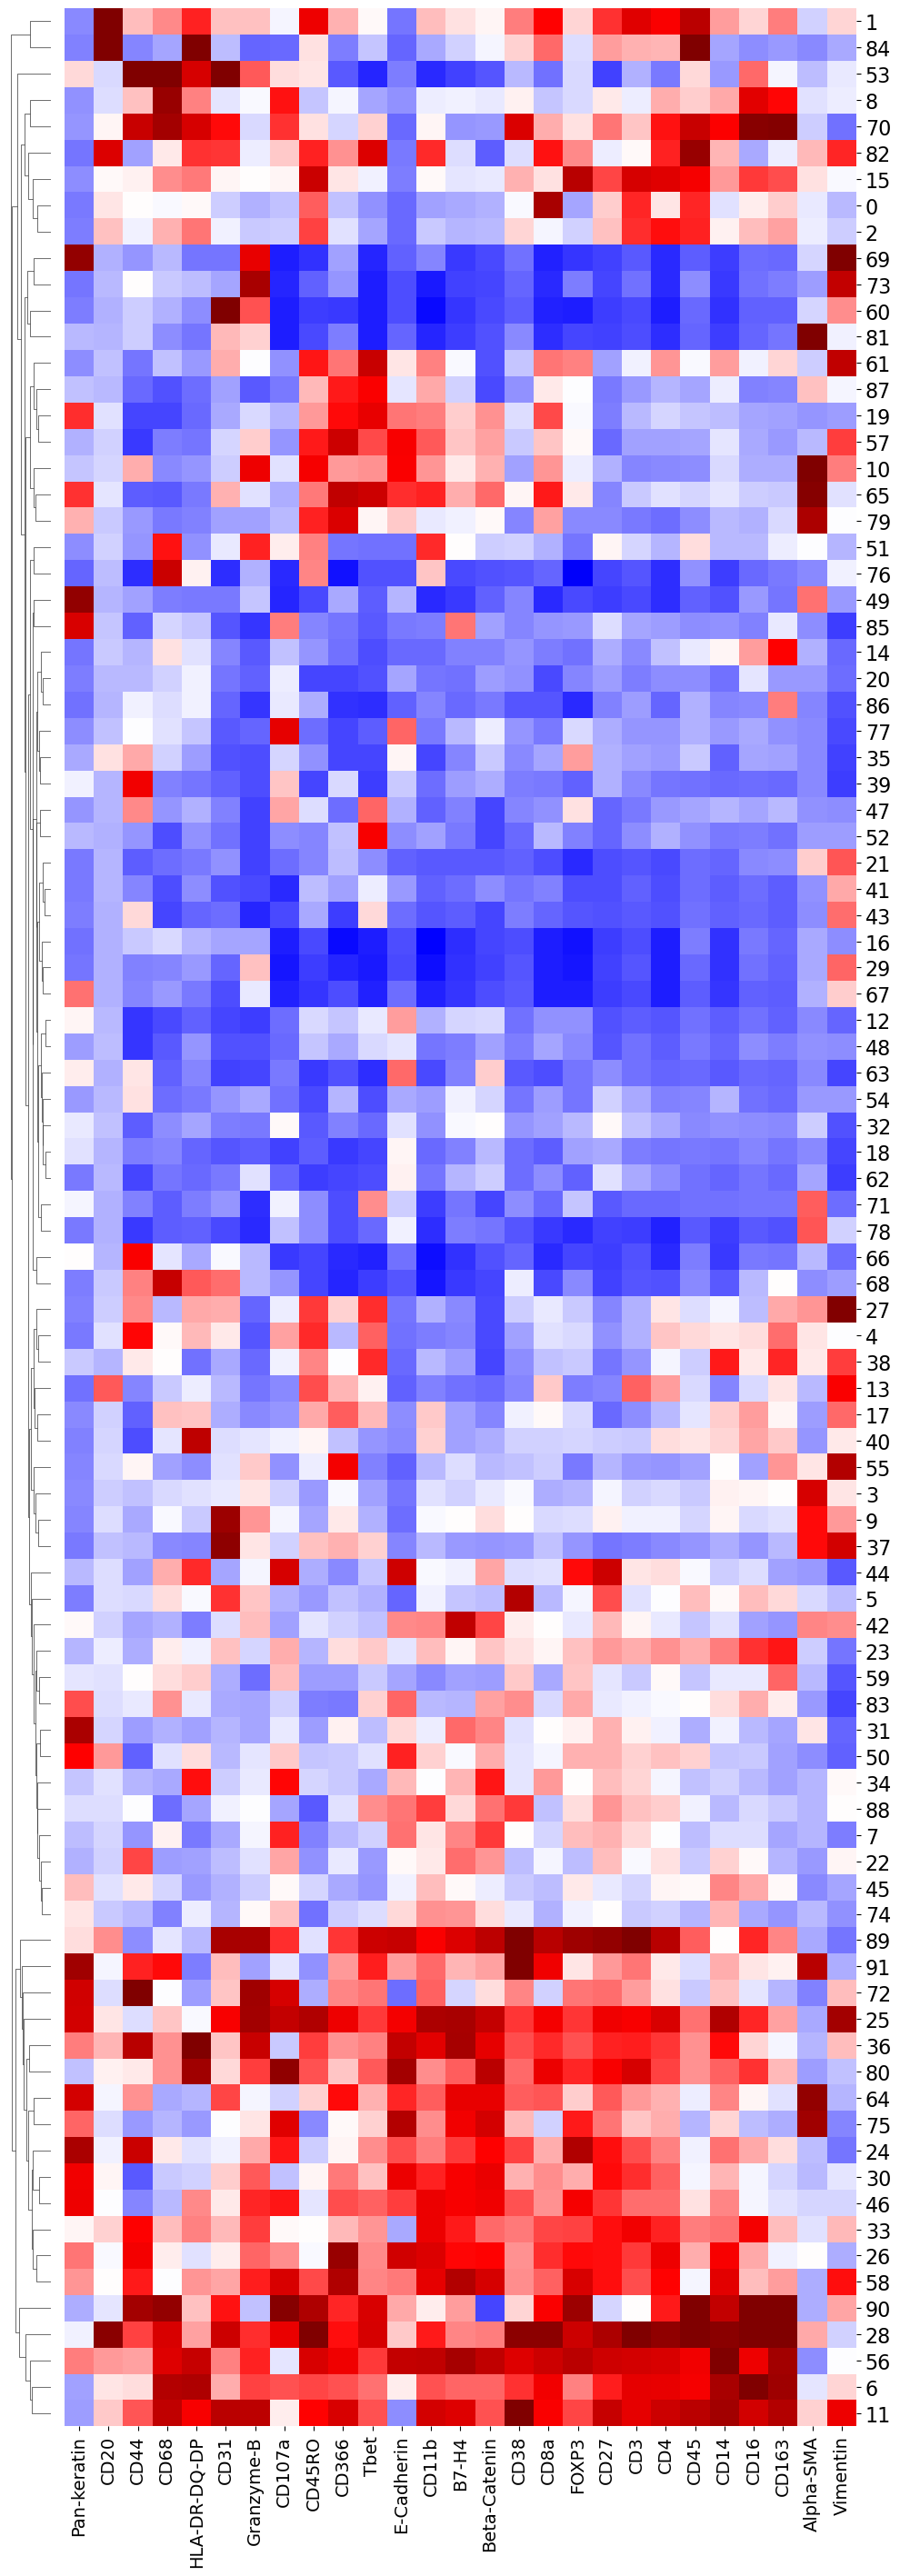

In [26]:

cg = sns.clustermap(cluster_mean_expr.T,z_score=1,cmap = 'seismic',vmin = -3,vmax = 3,dendrogram_ratio=0.05,figsize = (10,30),colors_ratio=0.5)
#cg.ax_row_dendrogram.set_visible(False)
cg.ax_col_dendrogram.set_visible(False)
cg.cax.set_visible(False)
cg.ax_heatmap.set_xticklabels(cg.ax_heatmap.get_xmajorticklabels(),fontsize = 14)
cg.ax_heatmap.set_yticklabels(cg.ax_heatmap.get_ymajorticklabels(),fontsize = 16)
_ = plt.setp(cg.ax_heatmap.get_yticklabels(), rotation=0)
plt.tight_layout()
#cg.savefig('phenograph_clustermap.png')

Int64Index([29, 73, 49, 67, 69, 66, 68, 16, 53,  9, 60,  3, 81, 10, 78, 71, 52,
            87, 65, 79, 57, 48, 12, 19, 82, 55, 21, 37, 13, 17, 38, 27, 43, 41,
            61, 91, 39, 72, 34, 80, 44, 77, 35, 20, 59, 31, 85, 63, 24, 83, 18,
            50, 36, 56, 33, 45, 26, 58, 22, 54, 42, 64, 88, 62, 89, 75,  7, 32,
            25, 30, 46, 74,  1, 84, 51, 76, 90,  4, 47, 86,  8, 14, 70, 40,  0,
            28,  2, 15,  5, 11,  6, 23],
           dtype='int64')

<Axes: >

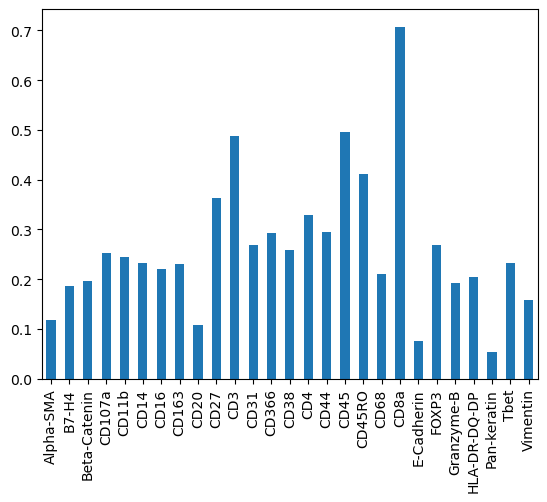

In [47]:
cluster_mean_expr[0].plot(kind = 'bar')

<Axes: >

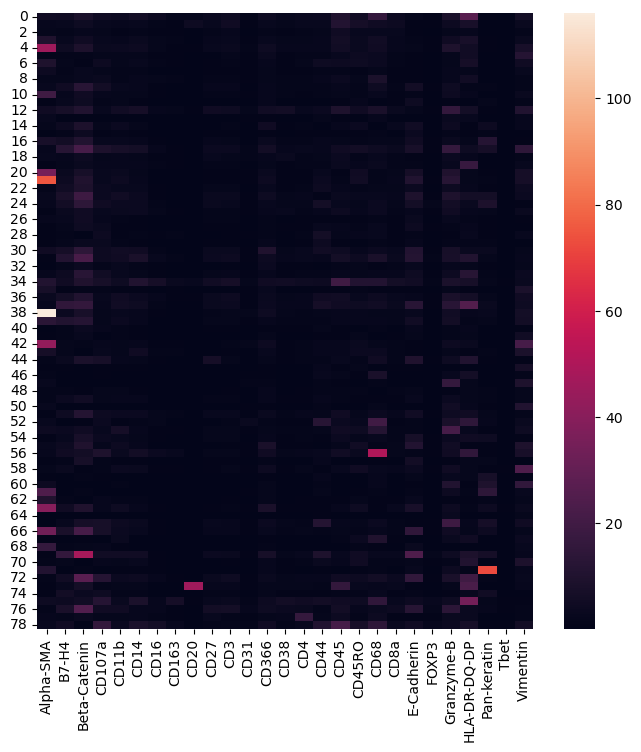

In [41]:
plt.figure(figsize =( 8,8))
sns.heatmap(cluster_mean_expr.T)


In [11]:
from sklearnex import patch_sklearn
patch_sklearn()
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
#from sklearn.model_selection import RandomizedSearchCV
from cuml.model_selection import GridSearchCV
from cuml.linear_model import LogisticRegression
from cuml import svm
from lightgbm import LGBMClassifier

######---------For SHAP/Model Explainations
import shap
from cuml.explainer import TreeExplainer
shap.initjs()

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


In [4]:
X = adata.X
y = np.array(list(adata.obs['pheno_louvain'].values),dtype = int)
X_train, X_val, y_train, y_val = train_test_split(X,y , test_size=0.2)


In [81]:
lr = LogisticRegression(C=0.01 ).fit(X_train, y_train)
#very low C to avoid having large coefficients

In [126]:
# Making predictions on the validation set
y_pred = lr.predict(X_val)

# Calculating accuracy on each validation set
accuracy = accuracy_score(y_val, y_pred)
print(accuracy_score(y_train,lr.predict(X_train)),accuracy)

0.802208861163817 0.8015162677710963


2.2259611612789887

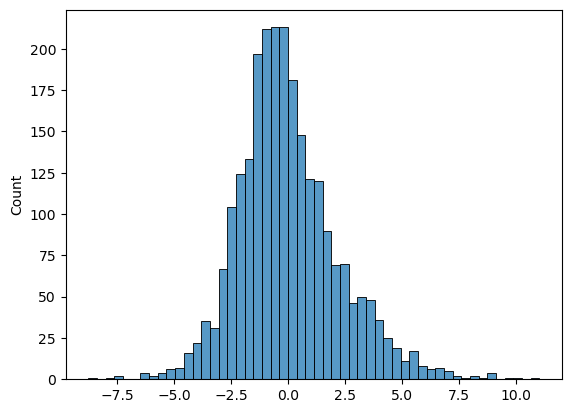

In [132]:
sns.histplot(lr.coef_.reshape(-1))
lr.coef_.reshape(-1).std()

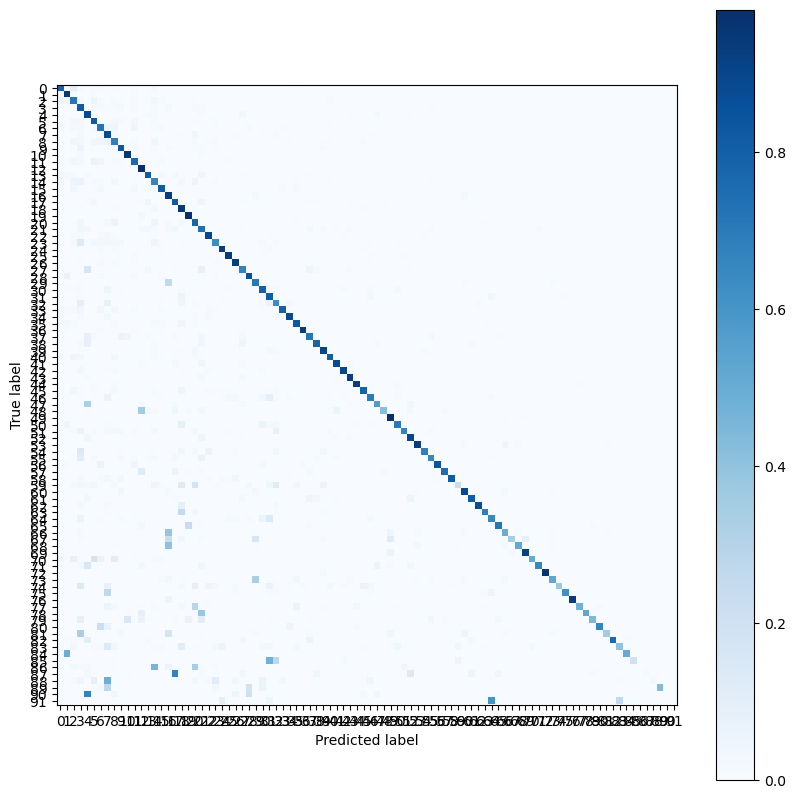

In [103]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
plt.figure(figsize = (10,10))
ConfusionMatrixDisplay.from_estimator(lr,X_val,y_val,normalize='true',ax = plt.gca(),cmap=plt.cm.Blues,include_values=False)

(92, 27)

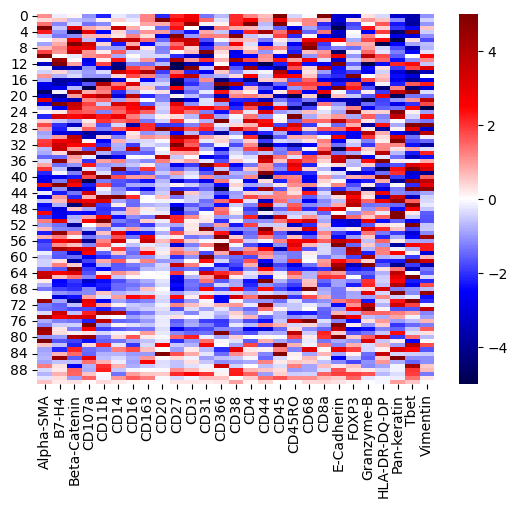

In [13]:
sns.heatmap(pd.DataFrame(lr.coef_,columns = adata.var.index),cmap = 'seismic',vmin = -5,vmax = 5)
lr.coef_.shape

In [123]:
annotation_table = pd.read_csv('~/devices/Delta_Tissue/IMC/IMC_data/IMCCelltypeResults/cell_type_matrix.csv',index_col=0)

annotation_table = annotation_table.drop(['Proliferative cells?', 'p53+ cells?', 'Neutrophil&monocyte',
       'Other cells'],axis = 1)
annotation_table = annotation_table[~annotation_table.isna().all(axis = 1)]
annotation_table.fillna(0,inplace=True)

<Axes: >

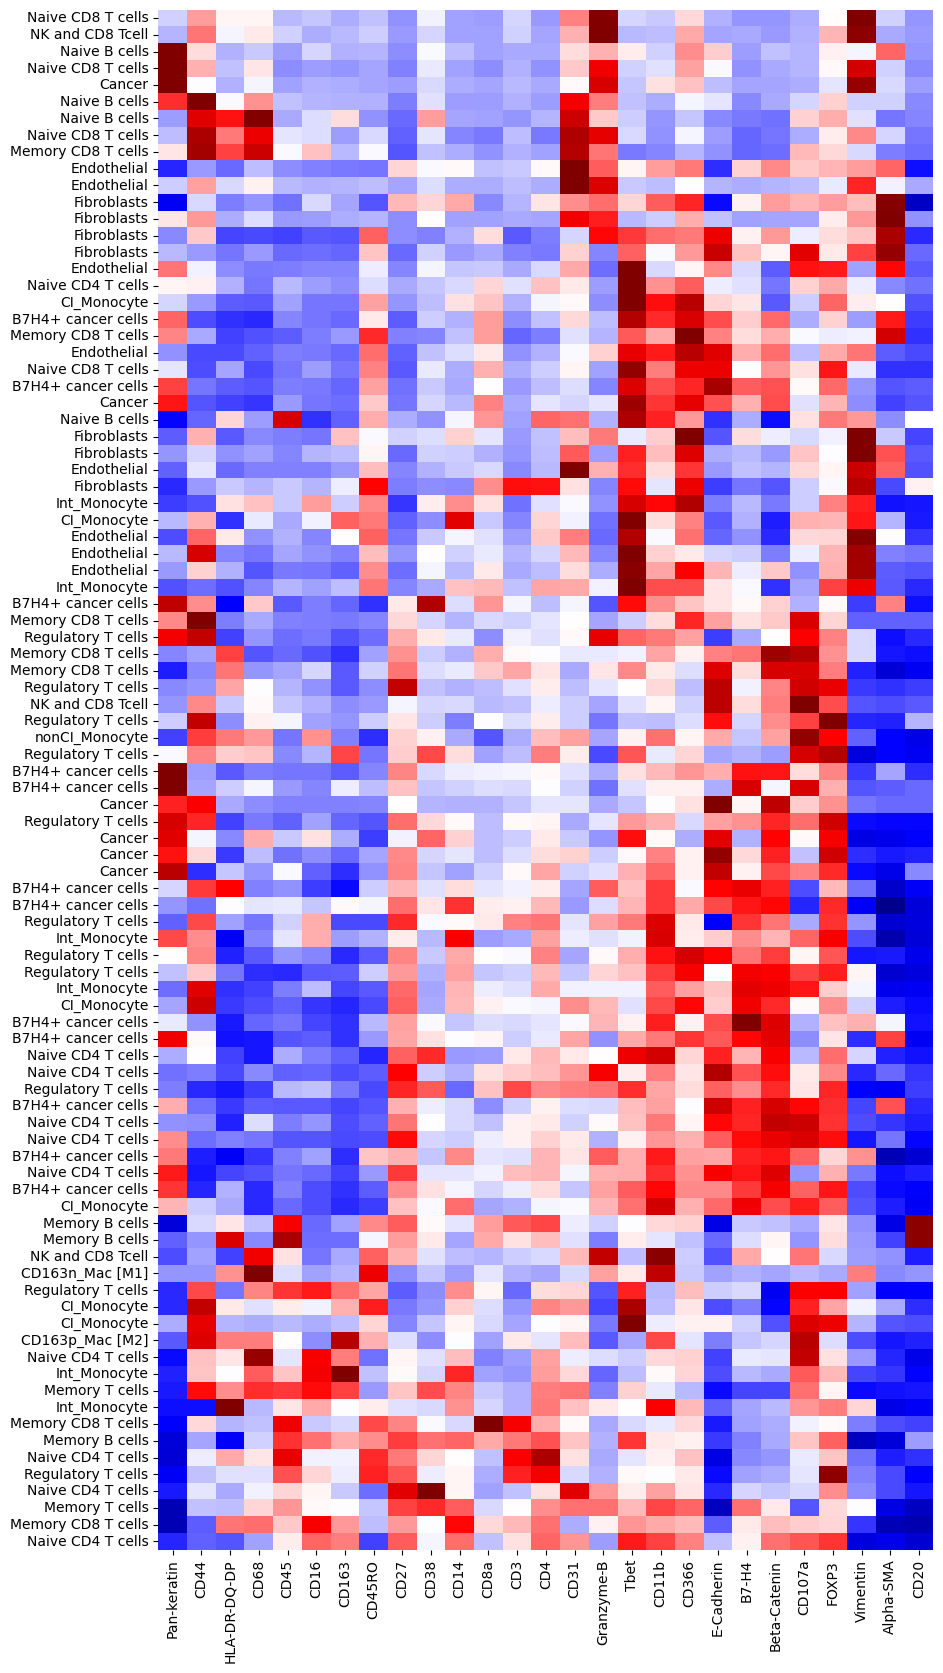

In [153]:
plt.figure(figsize = (10,20))
sns.heatmap(cg.data2d.rename(columns=score.idxmax(axis = 1)).T,cmap = 'seismic',vmin = -3,vmax = 3,cbar=False)

In [27]:
def softmax(score):
    return (np.exp(score).T/(np.exp(score).sum(axis = 1))).T
    

In [125]:
score = pd.DataFrame(lr.coef_,columns = adata.var.index).loc[:,annotation_table.index]@annotation_table

<Axes: >

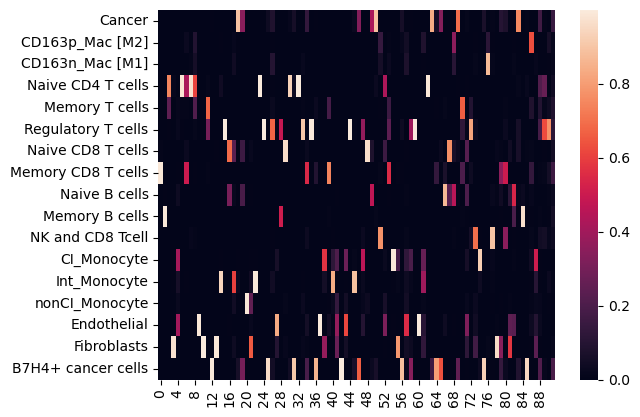

In [32]:
sns.heatmap(softmax(score).T)

0     Memory CD8 T cells
1         Memory B cells
2      Naive CD4 T cells
3            Fibroblasts
4            CI_Monocyte
             ...        
87           CI_Monocyte
88     Naive CD4 T cells
89    Regulatory T cells
90    Regulatory T cells
91    B7H4+ cancer cells
Length: 92, dtype: object

2.2225796742112545

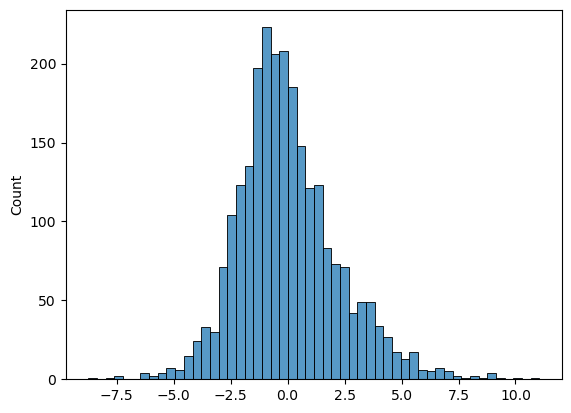

In [6]:
from cuml.explainer import TreeExplainer

In [9]:
#X = adata.X
#y = np.array(list(adata.obs['pheno_louvain'].values),dtype = int)
#X_train, X_val, y_train, y_val = train_test_split(X,y , test_size=0.2)

rf_classifier = RandomForestClassifier(n_estimators=7)
rf_classifier.fit(X_train, y_train)

RandomForestClassifier(n_estimators=7)

In [ ]:
# Making predictions on the validation set
y_pred = rf_classifier.predict(X_val)

# Calculating accuracy on each validation set
accuracy = accuracy_score(y_val, y_pred)
print(accuracy_score(y_train,rf_classifier.predict(X_train)),accuracy)

In [13]:
#d_train = lgb.Dataset(X_train, label=y_train)
#d_test = lgb.Dataset(X_val, label=y_val)

lgbm = LGBMClassifier(n_estimators=7)
lgbm.fit(X_train,y_train)
# Making predictions on the validation set
y_pred = lgbm.predict(X_val)

# Calculating accuracy on each validation set
accuracy = accuracy_score(y_val, y_pred)
print(accuracy_score(y_train,lgbm.predict(X_train)),accuracy)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032535 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6885
[LightGBM] [Info] Number of data points in the train set: 2410654, number of used features: 27
[LightGBM] [Info] Start training from score -2.981912
[LightGBM] [Info] Start training from score -2.986333
[LightGBM] [Info] Start training from score -3.038643
[LightGBM] [Info] Start training from score -3.094472
[LightGBM] [Info] Start training from score -3.287944
[LightGBM] [Info] Start training from score -3.312774
[LightGBM] [Info] Start training from score -3.513128
[LightGBM] [Info] Start training from score -3.583319
[LightGBM] [Info] Start training from score -3.603620
[LightGBM] [Info] Start training from score -3.625323
[LightGBM] [Info] Start training from score -3.620632
[LightGBM] [Info] Start training from score -3.6349

In [14]:
#explainer = shap.TreeExplainer(rf_classifier)
explainer = TreeExplainer(model = lgbm)

GradientBoostingClassifier(n_estimators=7)

In [17]:
%time shap_values = explainer.shap_values(X_val)


CPU times: user 8.61 s, sys: 1.32 s, total: 9.93 s
Wall time: 9.89 s


In [33]:
shap_values.shape

(92, 602664, 27)

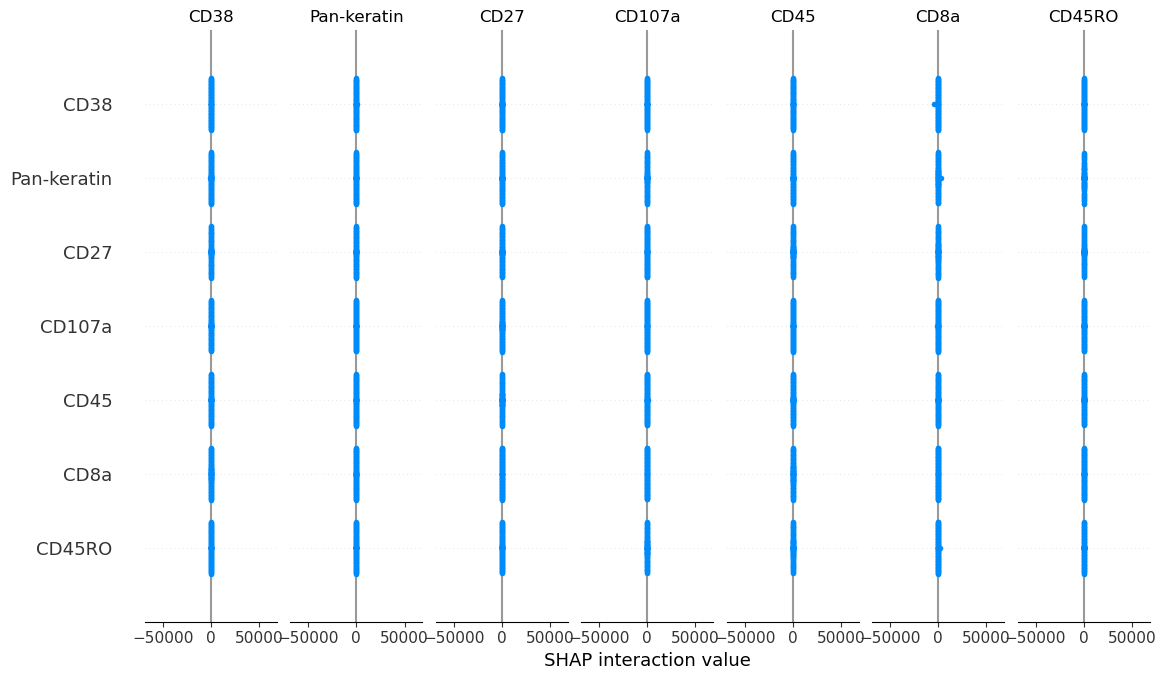

In [41]:
shap.summary_plot(shap_values,feature_names=adata.var.index)

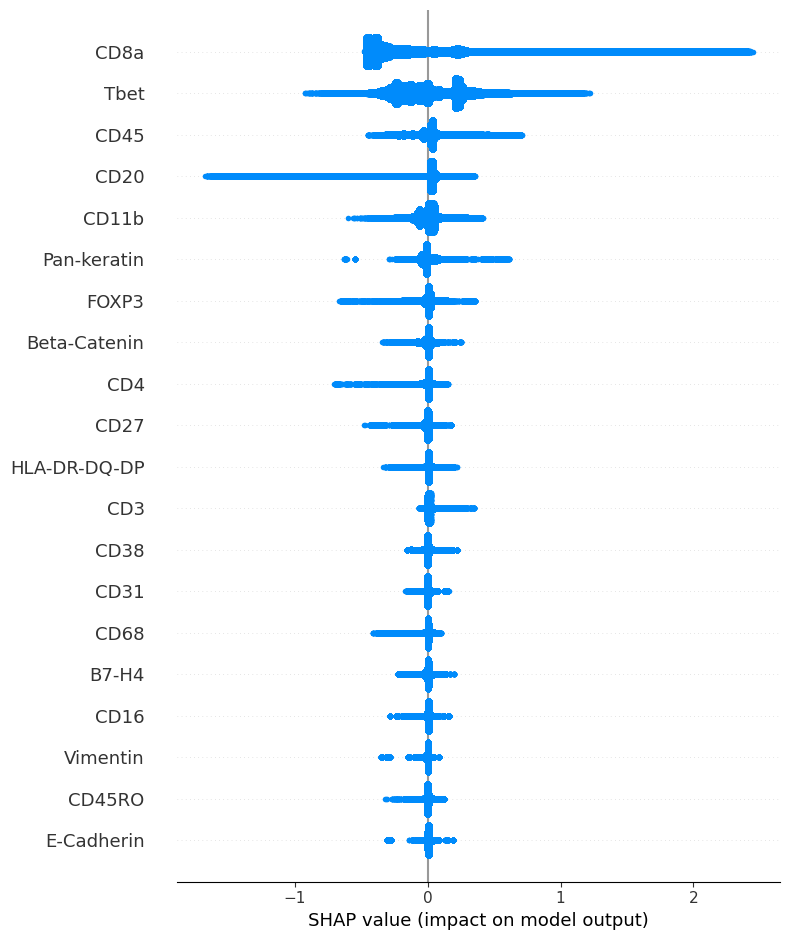

In [42]:
shap.summary_plot(shap_values[0],feature_names=adata.var.index)

In [32]:
shap.force_plot(explainer.expected_value[1], shap_values[1][0, :], X_val[0, :])


In [21]:
from cuml.ensemble import 
# Extracting feature importances
feature_importances = rf_classifier.feature_importances_

# Sorting feature importances in descending order
sorted_indices = feature_importances.argsort()[::-1]

# Plotting feature importances
plt.figure(figsize=(10, 6))
plt.bar(range(X.shape[1]), feature_importances[sorted_indices])
plt.xticks(range(X.shape[1]), adata.var.index[sorted_indices],rotation = 90)
plt.xlabel('Feature Index (Sorted by Importance)')
plt.ylabel('Feature Importance')
plt.title('Random Forest Feature Importances')

ImportError: cannot import name 'GradientBoostingClassifier' from 'cuml.ensemble' (/home/giuseppe/anaconda3/envs/rapids-23.10/lib/python3.10/site-packages/cuml/ensemble/__init__.py)

In [20]:
gbc= GradientBoostingClassifier(n_estimators=100,random_state=1200)
gbc.fit(X_train,Y_train)

feature_importances = pd.Series(gbc.feature_importances_, index=X_train.columns)

print('Score of Gradient Boosting model on test split\n',clf.score(X_test,Y_test))

Index(['Alpha-SMA', 'B7-H4', 'Beta-Catenin', 'CD107a', 'CD11b', 'CD14', 'CD16',
       'CD163', 'CD20', 'CD27', 'CD3', 'CD31', 'CD366', 'CD38', 'CD4', 'CD44',
       'CD45', 'CD45RO', 'CD68', 'CD8a', 'E-Cadherin', 'FOXP3', 'Granzyme-B',
       'HLA-DR-DQ-DP', 'Pan-keratin', 'Tbet', 'Vimentin'],
      dtype='object')

In [21]:
feature_importances

array([0.11321884, 0.03652939, 0.05138651, 0.03019046, 0.0267333 ,
       0.02478168, 0.01729562, 0.01365442, 0.02494772, 0.03994624,
       0.02728697, 0.01922227, 0.03106248, 0.02657191, 0.02073938,
       0.03602503, 0.04403589, 0.02847471, 0.05999943, 0.01956367,
       0.04971919, 0.0206965 , 0.03702628, 0.07809192, 0.04316848,
       0.03043297, 0.04919876])

In [3]:
!pip install scikit-learn-intelex

In [4]:
!which pip

/home/giuseppe/anaconda3/bin/pip


In [55]:
import importlib
importlib.reload(shap)

ModuleNotFoundError: spec not found for the module 'shap'

In [56]:
shap

<module 'shap' from '/home/giuseppe/anaconda3/envs/rapids-23.10/lib/python3.10/site-packages/shap/__init__.py'>

In [121]:
adata.obsm['spatial']

array([[8.50000000e-01, 1.48800000e+02],
       [1.10714286e+00, 2.37250000e+02],
       [1.11764706e+00, 1.37647059e+01],
       ...,
       [1.01774074e+03, 2.66074074e+02],
       [1.01817647e+03, 3.04470588e+02],
       [1.01771429e+03, 3.79428571e+02]])